# SQL Optimizer Advisor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/query-optimizer/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/query-optimizer/demo.ipynb)

> Slow queries, no idea why? This lints SQL for the anti-patterns that quietly force full table scans.

You don't need a cost-based optimizer to catch the *usual suspects*. A `LIKE '%x'`, a `YEAR(col) =`,
a comma-join with no join key - these turn a fast query into a full scan every time. This build is a
**SQL linter**: it flags those patterns, explains why each one hurts, and shows the rewrite.

**What this notebook covers**
1. The anti-patterns that kill query performance
2. A static analyzer that flags them (no DB needed)
3. A query-health score
4. A slow query vs a clean one
5. Where the score comes from, visualized


## Step 1 - A realistically slow query

Comma-join with no join condition, `SELECT *`, a function on a column in `WHERE`, a leading-wildcard
`LIKE`, and an `ORDER BY` with no `LIMIT`. Every one is a common, real mistake.

In [1]:
from optimizer import analyze_query, SAMPLE_QUERIES

slow = SAMPLE_QUERIES["Slow dashboard query"]
print(slow)


SELECT *
FROM orders o, customers c
WHERE YEAR(o.created_at) = 2026
  AND c.name LIKE '%acme%'
ORDER BY o.created_at


## Step 2 - Lint it

Each finding names the anti-pattern, *why* it's slow, and the fix. The most damaging is the
comma-join with no predicate - a Cartesian product hiding in plain sight.

In [2]:
report = analyze_query(slow)
print(f"Health score: {report.score()}/100\n")
for f in sorted(report.findings, key=lambda x: {"high":0,"medium":1,"low":2}[x.severity]):
    print(f"[{f.severity.upper():<6}] {f.issue}")
    print(f"         why: {f.why}")
    print(f"         fix: {f.suggestion}\n")


Health score: 3/100

[HIGH  ] LIKE '%...' can't use an index
         why: A leading wildcard forces a full scan - the index is useless.
         fix: Anchor the pattern ('abc%'), or use full-text search / a trigram index.

[HIGH  ] Function wrapped around a column in WHERE
         why: Wrapping a column in a function stops the index being used (non-sargable).
         fix: Rewrite so the column is bare, e.g. col >= '2026-01-01' instead of YEAR(col)=2026.

[HIGH  ] Comma join without a join condition
         why: Missing join predicate = Cartesian product (rows explode).
         fix: Use explicit JOIN ... ON, or add the join keys in WHERE.

[MEDIUM] SELECT * pulls every column
         why: Reads and transfers columns you don't use; blocks covering indexes.
         fix: List only the columns you need.

[LOW   ] No LIMIT on a row-returning query
         why: Exploratory queries without LIMIT can return millions of rows.
         fix: Add LIMIT while exploring.

[LOW   ] ORDER BY wi

## Step 3 - A clean query scores 100

The linter is specific, not paranoid: an explicit JOIN with a real key, named columns, a sargable
filter, and a LIMIT sail through untouched.

In [3]:
clean = SAMPLE_QUERIES["Clean query"]
print(clean)
print(f"\nHealth score: {analyze_query(clean).score()}/100")
print("Findings:", [f.rule for f in analyze_query(clean).findings] or "none")


SELECT o.id, o.amount, c.region
FROM orders o
JOIN customers c ON c.id = o.customer_id
WHERE o.created_at >= '2026-01-01'
LIMIT 100

Health score: 100/100
Findings: none


## Step 4 - The subtlety: a join key vs a filter

The trap in detecting a cross-join: `YEAR(o.created_at) = 2026` has an `=` and a dotted column, but
it's a *filter*, not a *join key*. Only `a.col = b.col` (column = column) counts. Getting this wrong
means either missing real Cartesian products or crying wolf on every filtered query.

In [4]:
import re

def has_real_join_key(sql):
    return re.search(r"\b\w+\.\w+\s*=\s*\w+\.\w+", sql.lower()) is not None

print("Slow query has a real join key? ", has_real_join_key(slow), " -> flagged as cross-join")
print("Clean query has a real join key?", has_real_join_key(clean), " -> not flagged")


Slow query has a real join key?  False  -> flagged as cross-join
Clean query has a real join key? True  -> not flagged


## Step 5 - Score breakdown, visualized

The health score docks points by severity, so one full-scan-causing issue outweighs a handful of
nits. Here's where the slow query lost its points.

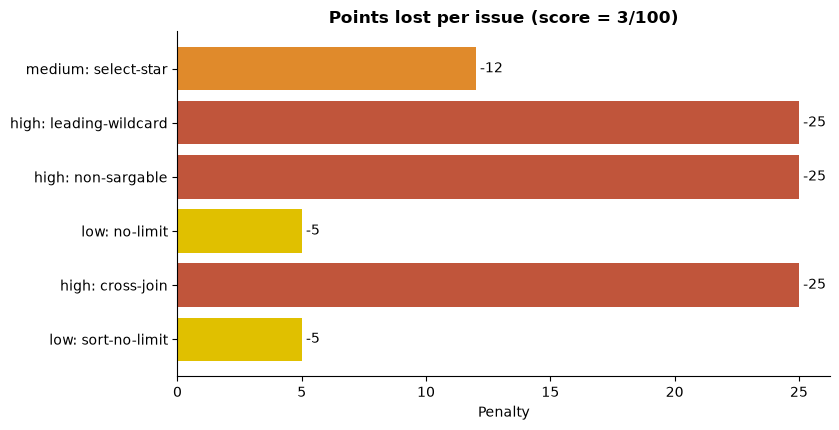

In [5]:
import matplotlib.pyplot as plt

weights = {"high": 25, "medium": 12, "low": 5}
findings = analyze_query(slow).findings
labels = [f"{f.severity}: {f.rule}" for f in findings]
penalties = [weights[f.severity] for f in findings]
colors = {"high": "#c0553b", "medium": "#e08a2b", "low": "#e0c000"}
bar_colors = [colors[f.severity] for f in findings]

fig, ax = plt.subplots(figsize=(8.5, 4.4))
bars = ax.barh(labels[::-1], penalties[::-1], color=bar_colors[::-1])
ax.set_title(f"Points lost per issue (score = {analyze_query(slow).score()}/100)", fontsize=12, weight="bold")
ax.set_xlabel("Penalty")
ax.bar_label(bars, fmt="-%d", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("score_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Anti-pattern | Severity | Why it's slow |
|--------------|----------|---------------|
| comma-join, no key | high | Cartesian product |
| function on column | high | non-sargable, no index |
| leading-wildcard LIKE | high | index unusable |
| SELECT * | medium | reads unused columns |
| ORDER BY / no LIMIT | low | wasted sort |

A linter won't replace `EXPLAIN`, but it catches the mistakes that cause most "why is this slow?"
tickets - before the query ever hits the warehouse.

**Extend it:** run it in CI on your dbt/SQL files, feed real `EXPLAIN` plans for cost-based
suggestions, and let Claude propose the full rewritten query.

In [6]:
# --- Try your own query ---
# r = analyze_query("""SELECT * FROM events WHERE lower(email) = 'x'""")
# print(r.score(), [f.rule for f in r.findings])


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 108,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`